# Lab 2: From Raw Data to ML-Ready Data
## Data Cleaning & Exploratory Data Analysis — Telco Customer Churn

**Name:** Tahira

**Roll Number:** 023-24-0266





---

## Setup

Import the libraries you'll need and load the dataset. Use the Telco Customer Churn CSV provided for this lab.

In [ ]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
df = pd.read_csv("C:\\ML COURSE\\archive\\Telco-Customer-Churn.csv")   # update path/filename if different


---

## Part 1 — The Business Problem

A telecommunications company is losing customers to competitors — this is called **customer churn**. The company wants to understand which customers are likely to leave, so it can intervene early. Before any model can be built, the raw data must be understood, audited for quality issues, and explored.

**Tasks**
1. In 2–3 sentences, state the business problem in your own words, and propose what the target variable likely is.
2. List 5 columns you expect to be useful predictors of churn, and 2 columns you expect to be useless as predictors — justify each choice in one line.
3. Write down 2 questions you personally want this data to answer about customers who churn.

**Answer 1:**
_The problem is simple. The telecom company wants to know why the customers are moving towards a new network by analyzing the data. The target variable is likely churn which tells us about the ratio of customers moving towards a new network.

**Answer 2:**
tenure: shows how long the customer has stayed with the company.
contract: diff contact types may have different churn rates.
monthly/Charges: higher/lower monthly charges may be related to churn.
InternetService: Different internet services may have different churn patterns.
PaymentMethod: Payment method may be associated with customers behavior and churn.


**Answer 3:**
1. Do customers with shorter tenure have a higher churn rate?
2. Does the type of contract affect the likelihood of customer churn?

---

## Part 2 — Exploring the Dataset Structure

Before cleaning or analyzing anything, get an accurate picture of the dataset's shape and contents. Running a command is not the same as understanding its output — you must interpret what you see.

*Concepts/functions you may find useful:* `df.shape`, `df.columns`, `df.dtypes`, `df.info()`, `df.head()`, `df.sample(n)`, `df[col].unique()`, `df[col].nunique()`, `df.describe(include='all')`

**Tasks**
4. How many customers and how many features are in this dataset? List the numerical features and the categorical features separately.
5. Identify any column(s) that are simply identifiers rather than predictive features, and any column(s) whose data type looks wrong for what it represents.
6. Pick 3 categorical columns and report their unique values — do any contain unexpected or inconsistent categories?

In [ ]:

# Task 4 — dataset shape, column names, data types
import pandas as pd

df = pd.read_csv("C:\\ML COURSE\\archive\\Telco-Customer-Churn.csv")  # update path/filename if different

print(df.shape)
print(df.dtypes)
print(df.columns)


(7043, 21)
customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object
Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')


In [ ]:
# Task 5 — identify identifier columns / wrong data types
# Answer:
# customerID is the identifier column because it uniquely represents each customer.
# totalCharges datatype is object but it should be int or float because it represents a number.

In [ ]:
# Task 6 — unique values in 3 categorical columns
print(df['gender'].unique())
print(df['Contract'].unique())
print(df['InternetService'].unique())

# everything seems okay the values are fine.



['Female' 'Male']
['Month-to-month' 'One year' 'Two year']
['DSL' 'Fiber optic' 'No']


**Observations (Part 2):**
_(summarize what you found — numerical features, categorical features, suspicious columns, etc.)_

---

## Part 3 — Investigating Data Quality

A dataset can look clean at a glance and still hide serious problems. You must actively search for missing values, duplicates, and suspicious values rather than assume there are none.

*Concepts/functions you may find useful:* `df.isnull().sum()`, `df.isnull().mean()*100`, `df.duplicated().sum()`, `df['id_col'].duplicated().sum()`, `df[col].value_counts()`

**Tasks**
7. Report missing values as both a count and a percentage per column. Which missing-value problems do you think require action, and which don't? Justify your reasoning.
8. Check for duplicate rows and duplicate customer IDs separately — are they the same issue or different issues?
9. Find at least one column with a suspicious, invalid, or inconsistently formatted value, and describe how you found it.

In [ ]:
# Task 7 — missing values: count and percentage per column

missing_count = df.isnull().sum()
missing_percentage = df.isnull().mean()*100

missing_summary = pd.DataFrame({
    "Missing Count": missing_count,
    "Missing Percentage": missing_percentage
})

print(missing_summary)

result = df["TotalCharges"].astype(str).str.strip().eq("").sum()
print(result)


                  Missing Count  Missing Percentage
customerID                    0                 0.0
gender                        0                 0.0
SeniorCitizen                 0                 0.0
Partner                       0                 0.0
Dependents                    0                 0.0
tenure                        0                 0.0
PhoneService                  0                 0.0
MultipleLines                 0                 0.0
InternetService               0                 0.0
OnlineSecurity                0                 0.0
OnlineBackup                  0                 0.0
DeviceProtection              0                 0.0
TechSupport                   0                 0.0
StreamingTV                   0                 0.0
StreamingMovies               0                 0.0
Contract                      0                 0.0
PaperlessBilling              0                 0.0
PaymentMethod                 0                 0.0
MonthlyCharg

In [ ]:
# Task 8 — duplicate rows vs duplicate IDs
duplicate_rows = df.duplicated().sum()
print(duplicate_rows)

duplicated_id = df["customerID"].duplicated().sum()
print(duplicated_id)

0
0


In [ ]:
# Task 9 — investigate a suspicious / invalid value
print(df["TotalCharges"].dtype)
print(df["TotalCharges"].unique())


blank_totalcharges = (
    df["TotalCharges"]
    .astype(str)
    .str.strip()
    .eq("")
    .sum()
)

print("Blank values in TotalCharges:", blank_totalcharges)

object
['29.85' '1889.5' '108.15' ... '346.45' '306.6' '6844.5']
Blank values in TotalCharges: 11


**Answer 7 (which missing-value problems need action, and why):**
first I checked the weather the data contain the na values. The answer was shocking. There were zero na values.
Then I tried to find the missing values and eventually i found 11 missing values.

**Answer 8 (duplicate rows vs duplicate IDs — same issue or different?):**
no duplicated rows or id found.

**Answer 9 (suspicious value found and how):**
first of all the totalCharges column is of object type rather than numerical or float. Furthermore,  there are 11 blank values in it.

---

## Part 4 — Data Cleaning Decisions

Cleaning is a series of justified decisions, not a fixed recipe. For every issue you fix, you must be able to explain why you chose that method over an alternative.

*Concepts/functions you may find useful:* `pd.to_numeric(s, errors='coerce')`, `df.fillna(value)`, `df.dropna()`, `df.drop_duplicates()`, `df[col].str.strip()`, `df.astype(dtype)`

**Tasks**
10. For every data-quality issue you found in Part 3, record: Problem → Decision → Method Used → Reason.
11. Apply your cleaning decisions to produce an intermediate cleaned dataframe, and confirm (with code output) that each issue is actually resolved.

**Task 10 — Cleaning Decision Log**

Blank values in `TotalCharges`

Problem: Some values are blank.
Decision: Convert blanks into missing values.
Method: pd.to_numeric(..., errors="coerce")`
Reason:`TotalCharges` should contain numerical values.

Duplicate rows

Problem: Some records may be repeated.
Decision: Remove duplicate rows.
Method: `drop_duplicates()`
Reason: Duplicates can affect the analysis.

Duplicate customer IDs

Problem: A customer ID may appear more than once.
Decision: Investigate and remove if they are duplicate customers.
Method: Check duplicate IDs.
Reason: Each customer should normally have one record.

Extra whitespace

Problem: Some values may contain unnecessary spaces.
Decision: Remove extra whitespace.
Method: .str.strip()`
Reason: Prevents inconsistent category values.

11 Blank Values in `TotalCharges`

Problem: 11 blank values are present in `TotalCharges`.

Decision: Treat them as missing values and remove these rows.

Method Used: Convert `TotalCharges` to numeric using `pd.to_numeric(..., errors="coerce")`, then use `dropna()`.

Reason: All 11 customers have `tenure = 0`, so there is not enough information to determine a meaningful `TotalCharges` value. Removing these few rows avoids inventing financial values.




In [ ]:
# Task 11 — apply your cleaning decisions here
clean_df = df.copy()
clean_df["TotalCharges"] = clean_df["TotalCharges"].astype(str).str.strip()
clean_df["TotalCharges"] = pd.to_numeric(
    clean_df["TotalCharges"],
    errors="coerce"
)



clean_df.loc[
    clean_df["TotalCharges"].isnull(),
    ["customerID", "tenure", "MonthlyCharges", "Contract", "TotalCharges", "Churn"]
]

clean_df = clean_df.dropna(subset=["TotalCharges"])
print(clean_df["TotalCharges"].isnull().sum())



0


In [ ]:
# Task 11 (continued) — confirm each issue is resolved (e.g. re-check isnull().sum(), duplicated().sum(), dtypes)

print(clean_df["TotalCharges"].isnull().sum())

clean_df["TotalCharges"].dtype

clean_df.duplicated().sum()

clean_df["customerID"].duplicated().sum()

clean_df["TotalCharges"].astype(str).str.strip().eq("").sum()

clean_df.info()

0
<class 'pandas.core.frame.DataFrame'>
Index: 7032 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7032 non-null   object 
 1   gender            7032 non-null   object 
 2   SeniorCitizen     7032 non-null   int64  
 3   Partner           7032 non-null   object 
 4   Dependents        7032 non-null   object 
 5   tenure            7032 non-null   int64  
 6   PhoneService      7032 non-null   object 
 7   MultipleLines     7032 non-null   object 
 8   InternetService   7032 non-null   object 
 9   OnlineSecurity    7032 non-null   object 
 10  OnlineBackup      7032 non-null   object 
 11  DeviceProtection  7032 non-null   object 
 12  TechSupport       7032 non-null   object 
 13  StreamingTV       7032 non-null   object 
 14  StreamingMovies   7032 non-null   object 
 15  Contract          7032 non-null   object 
 16  PaperlessBilling  7032 non-null   object 
 17

---

## Part 5 — Univariate EDA

Look at individual variables in isolation before looking at relationships. Every chart must be followed by a written interpretation — a graph with no explanation earns no credit.

*Concepts/functions you may find useful:* `df[col].plot(kind='hist')` / `plt.hist()`, `df.boxplot(column=col)`, `df[col].value_counts().plot(kind='bar')`

**Tasks**
12. Visualize the distribution of at least 2 numerical features and 2 categorical features. For each chart, write 1–2 sentences on what you learned.
13. Do any numerical features show outliers or a skewed distribution? What might explain this?

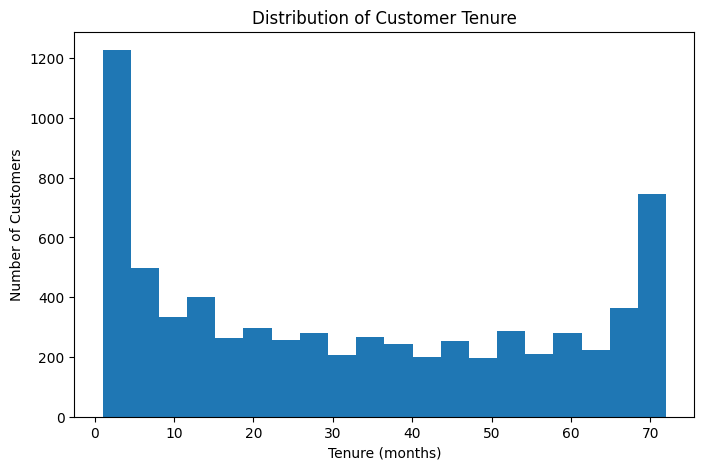

In [ ]:
# Task 12 — numerical feature 1: distribution plot
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.hist(clean_df["tenure"], bins=20)

plt.xlabel("Tenure (months)")
plt.ylabel("Number of Customers")
plt.title("Distribution of Customer Tenure")

plt.show()

**Observation:** The graph shows that the values are neither right skewed nor left skewed. It represents many newer customers and many long customers.

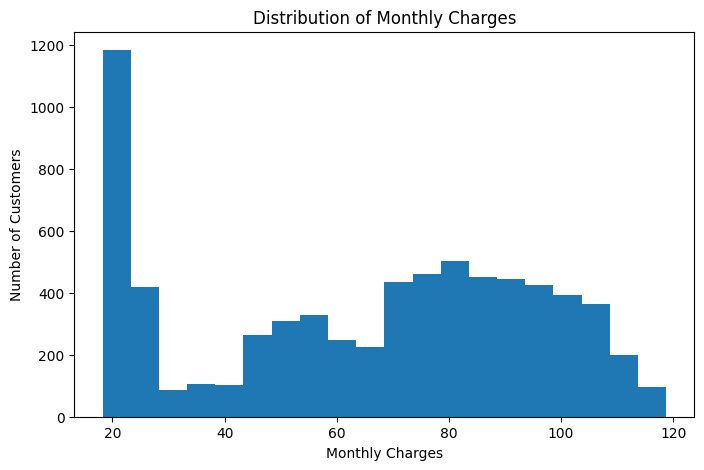

In [ ]:
# Task 12 — numerical feature 2: distribution plot
plt.figure(figsize=(8,5))
plt.hist(clean_df["MonthlyCharges"],bins=20)
plt.xlabel("Monthly Charges")
plt.ylabel("Number of Customers")
plt.title("Distribution of Monthly Charges")

plt.show()

**Observation:** from the chart we can see it is right skewed which tells us that most of the customers have relatively lower monthly charges.

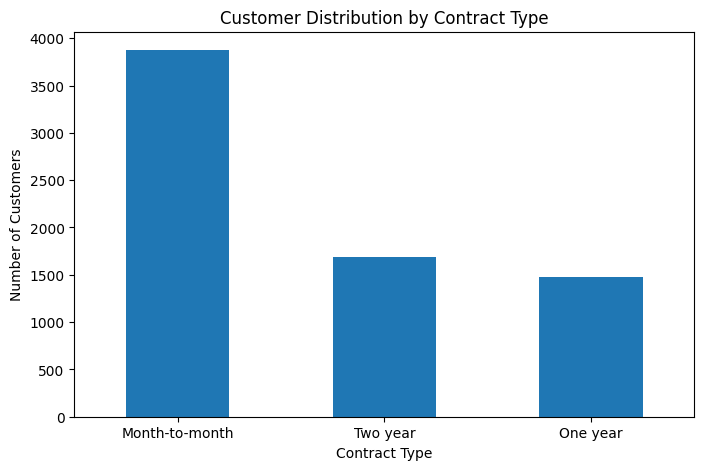

In [ ]:
# Task 12 — categorical feature 1: distribution plot
plt.figure(figsize=(8, 5))

clean_df["Contract"].value_counts().plot(kind="bar")

plt.xlabel("Contract Type")
plt.ylabel("Number of Customers")
plt.title("Customer Distribution by Contract Type")

plt.xticks(rotation=0)

plt.show()




**Observation:** we can see that month to month customers have relatively higher number of customers.

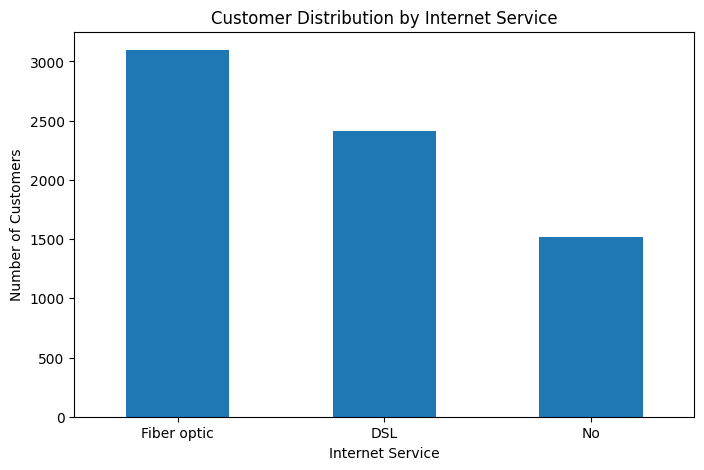

In [ ]:
# Task 12 — categorical feature 2: distribution plot
plt.figure(figsize=(8, 5))

clean_df["InternetService"].value_counts().plot(kind="bar")

plt.xlabel("Internet Service")
plt.ylabel("Number of Customers")
plt.title("Customer Distribution by Internet Service")

plt.xticks(rotation=0)

plt.show()


**Observation:** fibre optics has the higher customers

**Answer 13 (outliers / skew and possible explanation):** The tenure feature has a slight right skew, but its distribution is relatively close to symmetric. MonthlyCharges has a skewness indicating a slight left skew and is also relatively close to symmetric.


---

## Part 6 — Target Variable Analysis

The `Churn` column is what you will eventually predict. Before Lab 3, you need to understand its distribution — this has direct consequences for how a model should later be trained and evaluated.

*Concepts/functions you may find useful:* `df['Churn'].value_counts()`, `df['Churn'].value_counts(normalize=True)`

**Tasks**
14. Report the number and percentage of churned vs. non-churned customers. Is the target balanced or imbalanced?
15. In 2–3 sentences, explain why class imbalance might matter when a classification model is trained later — do not describe how to fix it, just why it matters.

In [ ]:
# Task 14 — churn counts and percentages
clean_df["Churn"].value_counts()

clean_df["Churn"].value_counts(normalize=True)*100

Churn
No     73.421502
Yes    26.578498
Name: proportion, dtype: float64

**Answer 14 (balanced or imbalanced?):**
imbalance

**Answer 15 (why imbalance might matter later):**
because of imbalance the future model may focus on the more heavy side and perform poorly.


---

## Part 7 — Bivariate Analysis: Features vs. Churn

Now connect individual features to the target. You choose the appropriate visualization or summary for each feature type — a categorical feature is not explored the same way as a numerical one.

*Concepts/functions you may find useful:* `pd.crosstab(df[col], df['Churn'], normalize='index')`, `df.groupby(col)['Churn']...`, `sns.boxplot(x='Churn', y=col, data=df)`

**Tasks**
16. Investigate at least 2 categorical features (e.g. Contract, InternetService, PaymentMethod) against Churn. For each, record: Observation / Evidence / Possible Explanation.
17. Investigate at least 2 numerical features (e.g. tenure, MonthlyCharges) against Churn using the same Observation / Evidence / Possible Explanation format.

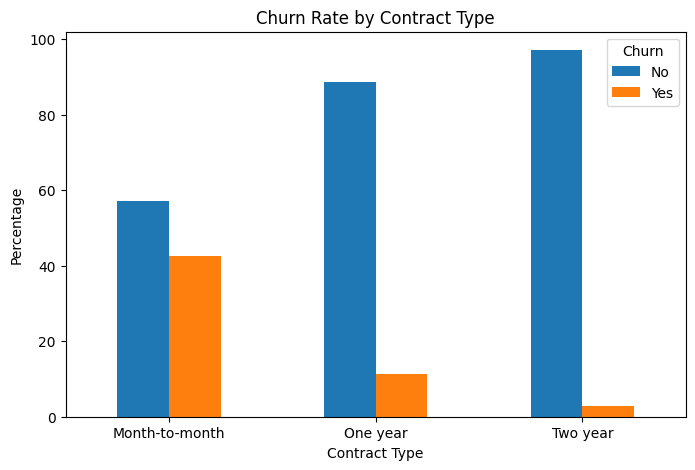

In [ ]:
# Task 16 — categorical feature 1 vs Churn
contract_churn = pd.crosstab(
    df["Contract"],
    df["Churn"],
    normalize = "index"
) * 100

contract_churn


contract_churn.plot(kind='bar', figsize=(8, 5))

plt.title('Churn Rate by Contract Type')
plt.xlabel('Contract Type')
plt.ylabel('Percentage')
plt.xticks(rotation=0)
plt.legend(title='Churn')
plt.show()

**Observation:** _..._ The month-to-month contracts have higher churn rate.
**Evidence:** _..._ we can see in the chart and through the percentage table.
**Possible Explanation:** _..._ Basically as the people are not bound to anything in month-to-month contract thats why they prefer to switch.

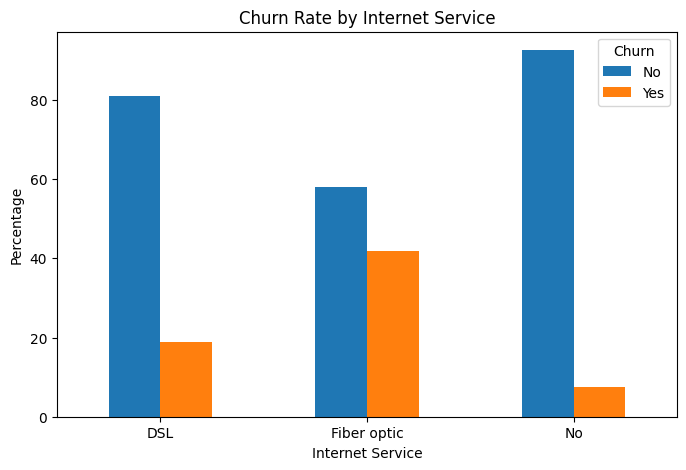

In [ ]:
# Task 16 — categorical feature 2 vs Churn
internet_churn = pd.crosstab(
    df['InternetService'],
    df['Churn'],
    normalize='index'
) * 100

internet_churn

internet_churn.plot(kind='bar', figsize=(8, 5))

plt.title('Churn Rate by Internet Service')
plt.xlabel('Internet Service')
plt.ylabel('Percentage')
plt.xticks(rotation=0)
plt.legend(title='Churn')
plt.show()

**Observation:** _..._ The fiber optic internet service people have higher churn rate.
**Evidence:** _..._visible throught the graph and percentage table.
**Possible Explanation:** _..._ The reason for this can be of high expectations from Internet speed or high bills.

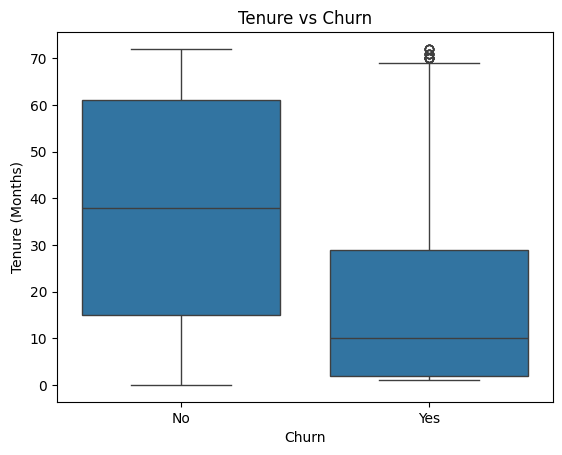

In [ ]:
# Task 17 — numerical feature 1 vs Churn
df.groupby("Churn")["tenure"].mean()

sns.boxplot(x='Churn', y='tenure', data=df)

plt.title('Tenure vs Churn')
plt.xlabel('Churn')
plt.ylabel('Tenure (Months)')
plt.show()

**Observation:** _..._ the graph shows that the churn is by new users  more.
**Evidence:** _..._ the graph shows the evidence. the tenure is less of people whose churn is yes.
**Possible Explanation:** _..._ The new users have low commitment and its easy for them to switch.

<Axes: xlabel='Churn', ylabel='MonthlyCharges'>

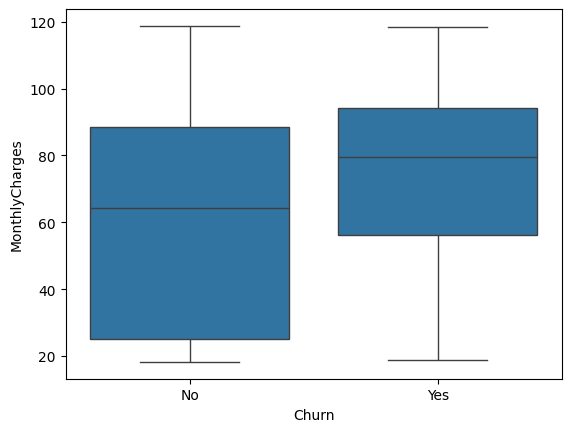

In [ ]:
# Task 17 — numerical feature 2 vs Churn
df.groupby("Churn")["MonthlyCharges"].mean()

sns.boxplot(x='Churn', y='MonthlyCharges', data=df)

**Observation:** _..._ The users that have higher monthly charges have higher churn rate and vice versa.
**Evidence:** _..._ the graph shows that people whose charges are more have yes churn and vice versa.
**Possible Explanation:** _..._ somestimes its hard for users to pay high bills and to save some money they might have switched to competitors.

---

## Part 8 — Correlation & Feature Relationships

Numerical features can be related to each other, not just to the target. Strongly correlated features can cause redundancy problems later, so it's worth knowing about them now.

*Concepts/functions you may find useful:* `df.corr(numeric_only=True)`, `sns.heatmap(corr_matrix, annot=True)`

**Tasks**
18. Compute and visualize the correlation matrix of the numerical features. Which pairs appear most correlated?
19. Does correlation imply causation here? Could any highly correlated features cause problems for a future model? Answer in 2–3 sentences.

<Axes: >

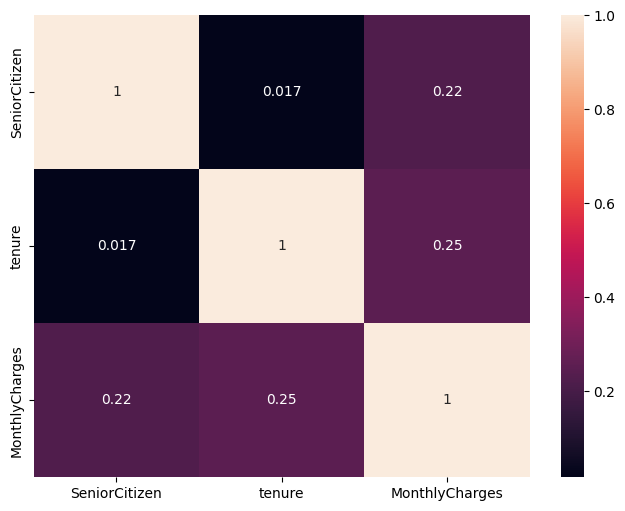

In [ ]:
# Task 18 — correlation matrix and heatmap
corr_matrix = df.corr(numeric_only = True)
corr_matrix

plt.figure(figsize = (8,6))
sns.heatmap(
    corr_matrix,
    annot=True
)

**Answer 18 (most correlated pairs):**
The graph shows that tenure and monthly charges are the most correlated pairs.

**Answer 19 (correlation vs. causation; potential problems):**
no. correlation does not mean causation. It just means that they are related in some way. Highly correlated features can provide redundant information and may cause problems for some machine-learning models, but the correlations in this dataset are relatively weak, so there is no major correlation issue among these numerical features.

---

## Part 9 — Data Leakage Awareness

In Lab 3 you will train a classifier. Before that, you must check whether any column contains information that would not realistically be available at the moment of prediction — using such a column would make a model look artificially accurate.

**Tasks**
20. Inspect the columns for anything that looks like it could only be known after a customer has already churned, or that is purely an identifier. List any suspects and explain your reasoning.
21. In 2–3 sentences, explain what would go wrong if such a column were left in the model's input features.

**Answer 20 (suspect columns and reasoning):**
The customerID column is used for identification only that has no use in the input and the output column that tells weather the customer has churn or not should also be excluded from the input.

**Answer 21 (what would go wrong):**
These these columns are included then the model will predict based on these columns but these columns would not be available at the time of real test which can cause good performance on test data but poor on real world usage.

---

## Part 10 — ML-Readiness Checklist

Summarize every column's fate in a single table. This is the bridge between EDA and modeling — Lab 3 will use this table directly.

**Task**
22. Complete the ML-readiness table for **every** column in the dataset.

| Column             | Type        | Role       | Action     | Reason                                                                 |
| ------------------ | ----------- | ---------- | ---------- | ---------------------------------------------------------------------- |
| `customerID`       | Identifier  | —          | **Remove** | only an identifier. Gives no additional info |
| `gender`           | Categorical | Feature    | **Keep**   | customer info provide krnta ha about gender.                    |
| `SeniorCitizen`    | Numerical   | Feature    | **Keep**   | it can be useful in senior citizen evaluation.       |
| `Partner`          | Categorical | Feature    | **Keep**   | tells about customers household.         |
| `Dependents`       | Categorical | Feature    | **Keep**   | gives info about dependents.                        |
| `tenure`           | Numerical   | Feature    | **Keep**   | from how long the user is with the company.                         |
| `PhoneService`     | Categorical | Feature    | **Keep**   | represents the phone service subscription.                     |
| `MultipleLines`    | Categorical | Feature    | **Keep**   | gives info about multiple phone lines.                          |
| `InternetService`  | Categorical | Feature    | **Keep**   | tells the type of internet service                                  |
| `OnlineSecurity`   | Categorical | Feature    | **Keep**   | represents Online security service.           |
| `OnlineBackup`     | Categorical | Feature    | **Keep**   | gives info of Online backup service.                         |
| `DeviceProtection` | Categorical | Feature    | **Keep**   | gives info about Device protection subscription.                 |
| `TechSupport`      | Categorical | Feature    | **Keep**   | tells about Technical support.                |
| `StreamingTV`      | Categorical | Feature    | **Keep**   | Streaming TV service is represented by this.                           |
| `StreamingMovies`  | Categorical | Feature    | **Keep**   | Streaming movies service are represented.                       |
| `Contract`         | Categorical | Feature    | **Keep**   | contract type can be related to churn.                           |
| `PaperlessBilling` | Categorical | Feature    | **Keep**   | tells about Billing preference.                            |
| `PaymentMethod`    | Categorical | Feature    | **Keep**   | tells the method of payment by customer.                                 |
| `MonthlyCharges`   | Numerical   | Feature    | **Keep**   | monthly charges of customers are represented by this.                    |
| `TotalCharges`     | Numerical   | Feature    | **Keep**   | represents the accumulated charges of Customer.                |
| `Churn`            | Categorical | **Target** | **Keep**   | this is the variable through which the model will learn.                      |


---

## Part 11 — Building the Clean Dataset

Bring together every cleaning decision into one final dataframe, `clean_df`, that Lab 3 can load directly.

> Do **not** split into train/test, encode categorical variables, or train any model — that happens in Lab 3.

**Tasks**
23. Produce `clean_df` with correct data types, missing values handled, duplicates handled, and irrelevant identifier columns removed where justified. Save it (e.g. `clean_churn.csv`) alongside your notebook.
24. Print `df.info()` (or equivalent) for `clean_df` as final proof that every issue identified earlier has been resolved.

In [ ]:
# Task 23 — assemble clean_df from your cleaning decisions
clean_df = df.copy()

# ... apply your cleaning steps here ...

clean_df["TotalCharges"] = clean_df["TotalCharges"].replace(' ',np.nan)
clean_df["TotalCharges"] = pd.to_numeric(clean_df["TotalCharges"])
clean_df["TotalCharges"] = clean_df["TotalCharges"].fillna(
    clean_df["TotalCharges"].median()
)
clean_df = clean_df.drop_duplicates()

clean_df = clean_df.drop(columns=["customerID"])


# Save the cleaned dataset
clean_df.to_csv("clean_churn.csv", index=False)


In [ ]:
# Task 24 — final proof: info() / isnull().sum() / duplicated().sum() on clean_df
clean_df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7043 non-null   object 
 1   SeniorCitizen     7043 non-null   int64  
 2   Partner           7043 non-null   object 
 3   Dependents        7043 non-null   object 
 4   tenure            7043 non-null   int64  
 5   PhoneService      7043 non-null   object 
 6   MultipleLines     7043 non-null   object 
 7   InternetService   7043 non-null   object 
 8   OnlineSecurity    7043 non-null   object 
 9   OnlineBackup      7043 non-null   object 
 10  DeviceProtection  7043 non-null   object 
 11  TechSupport       7043 non-null   object 
 12  StreamingTV       7043 non-null   object 
 13  StreamingMovies   7043 non-null   object 
 14  Contract          7043 non-null   object 
 15  PaperlessBilling  7043 non-null   object 
 16  PaymentMethod     7043 non-null   object 


---

## Part 12 — Key Findings & Final Reflection

Step back from the code and summarize what you actually learned about this dataset and this problem.

**Task 25 — Five Important Findings**

Repeat this block for each of your five findings.

**Finding 1** churn is higher among month-to-month customers
- Observation: _..._ customers who have month-to-month subscription have higher churn rate.
- Evidence: _..._ The contract vs churn graph showed us the evidence.
- Interpretation: _..._ As customers have no long term bouding they prefer to switch easily for a competitors.

**Finding 2**  customers with shorter tenure have higher churn rate.
- Observation: _..._  customers who have short tenure churn easily as compare to long term users.
- Evidence: _..._ we plotted a graph that clearly gave us this info.
- Interpretation: _..._ newer customers maybe less loyal and less satisfied due to high expectations.

**Finding 3**  monthly charges are related to churn
- Observation: _..._ customers who have higher monthly charges likely churn more.
- Evidence: _..._ The graph indicated this.
- Interpretation: _..._ higher charges can cause people leave or switch.

**Finding 4** Internet and other services churn differ.
- Observation: _..._ The users who have subscribed to internet services have higher churn rate as compare to other services.
- Evidence: _..._ above plotted graph between services and churn.
- Interpretation: _..._  The internet users may be facing dissatisfaction due to speed or other reasons due to which they prefer to switch.

**Finding 5** customerId is not predictive feature
- Observation: _..._  customerid only uniquely identifies the users. It does not provide any additional info.
- Evidence: _..._ table shows us that customerid is only for identification.
- Interpretation: _..._ customerid should be removed from the dataset because it not a predictive feature for our ml model.

---

**Task 26 — Final Reflection Questions**

1. What was the most important data-quality issue you found?
   The most important data-quality issue was the blank values in the TotalCharges column.
   
3. What was the most interesting pattern you discovered?
   The most interesting pattern was that customers with month-to-month contracts and shorter tenure showed higher churn behavior.

   
5. Which feature seems most useful for predicting churn?
   contract and tenure are most useful features found in the dataset because churn changes alot in these features.

6. Which feature should probably not be used, and why?
    customerid should not be used as it is and identifier and does not provide any additional info.

7. What preprocessing will be required before ML modeling (conceptually — do not implement it)?
   categorical variables need to be encoded into numerical form. numerical features may be checked for scaling. Also

8. What would you do next if you had another 3 hours?
   probably explore more features and see the relationships between them.

---

## Bonus Tasks (Optional)

- Create one additional meaningful visualization not required above.
- Investigate a surprising customer subgroup you didn't expect to find.
- Calculate churn rate across a combination of 2+ customer segments at once.
- Identify one possible feature-engineering opportunity for Lab 3.
- Identify one possible source of bias in this dataset.

In [ ]:
# Bonus — optional exploration



---

## Submission Checklist

Before submitting, confirm you have:

- [ ] Completed all 26 tasks above, with written interpretation for every chart and decision
- [ ] A working `clean_df`, saved as `clean_churn.csv`
- [ ] A completed ML-readiness table (Part 10) covering every column
- [ ] Five Key Findings written (Part 12)
- [ ] Answered all six Final Reflection questions
- [ ] Committed and pushed this notebook + `clean_churn.csv` to your GitHub repository
- [ ] Added your GitHub repository link at the top of this notebook